In [1]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

# --- helpers -------------------------------------------------
def kron_n(op_list):
    """Kronecker product of list of operators"""
    out = op_list[0]
    for op in op_list[1:]:
        out = np.kron(out, op)
    return out

def build_single_site_op(n, op, site):
    """Return I^{⊗site} ⊗ op ⊗ I^{⊗(n-site-1)}"""
    I2 = np.eye(2, dtype=complex)
    return kron_n([op if i == site else I2 for i in range(n)])

def lindblad_super(L, d):
    return (np.kron(L, L.conj()) -
            0.5 * np.kron(np.eye(d), L.conj().T @ L) -
            0.5 * np.kron((L.conj().T @ L).T, np.eye(d)))

# --- system parameters --------------------------------------
k = 4                      # number of atoms (small for demo)
V0 = 40 * 1e6  * 2*np.pi     # nearest-neighbour interaction (Hz)
t_ramp_up = 0.33e-6
t_ramp_down = 0.33e-6
t_sweep = 0.34e-6
T_total = t_ramp_up + t_sweep + t_ramp_down
Omega_max = 3e6 * 2*np.pi  # convert to angular freq
Delta_start = -4e6 * 2*np.pi
Delta_end   =  4e6 * 2*np.pi
T2 = 6e-6                 # coherence time (s)
gamma = 1 / T2
# gamma = 0 #use no decoherence
num_steps = 1000            # time slices
dt = T_total / num_steps
t_grid = np.linspace(0, T_total, num_steps)

# pauli matrices and projector
X = np.array([[0, 1], [1, 0]], dtype=complex)
Pr = np.array([[0, 0],
               [0, 1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

# --- ramp profiles ------------------------------------------
Omega_t = np.zeros_like(t_grid)
Delta_t = np.zeros_like(t_grid)
for idx, t in enumerate(t_grid):
    if t < t_ramp_up:
        Omega_t[idx] = Omega_max * (t / t_ramp_up)
        Delta_t[idx] = Delta_start
    elif t < t_ramp_up + t_sweep:
        Omega_t[idx] = Omega_max
        s = (t - t_ramp_up) / t_sweep
        Delta_t[idx] = Delta_start + (Delta_end - Delta_start) * s
    else:
        Omega_t[idx] = Omega_max * (1 - (t - t_ramp_up - t_sweep) / t_ramp_down)
        Delta_t[idx] = Delta_end

# --- precompute single‑site ops ------------------------------
X_ops = [build_single_site_op(k, X, j) for j in range(k)]
Pr_ops = [build_single_site_op(k, Pr, j) for j in range(k)]

# initial state |0...0⟩
d = 2**k
rho = np.zeros((d, d), dtype=complex)
rho[0, 0] = 1.0
rho_vec = rho.flatten()

# precompute Liouvillian components that don't change with time
L_jump_total = np.zeros((d*d, d*d), dtype=complex)
for j in range(k):
    L_jump_total += lindblad_super(np.sqrt(2*gamma) * Pr_ops[j], d)


# stuff to keep track of
populations = np.zeros((num_steps, d), dtype=float)

# --- time evolution -----------------------------------------
for idx in range(num_steps):
    # build instantaneous Hamiltonian H(t)
    H_drive = sum(Omega_t[idx]/2 * X_ops[j] for j in range(k))
    H_det   = sum(-Delta_t[idx] * Pr_ops[j] for j in range(k))
    H_int = sum(V0 * Pr_ops[i] @ Pr_ops[i+1] for i in range(k - 1)) + V0 * Pr_ops[k-1] @ Pr_ops[0]
    H_t = H_drive + H_det + H_int

    L_coherent = -1j * (np.kron(H_t, np.eye(d)) - np.kron(np.eye(d), H_t.T))
    L_total = L_coherent + L_jump_total

    # propagate one step
    U = expm(L_total * dt)
    rho_vec = U @ rho_vec

    populations[idx] = np.real(np.diag(rho_vec.reshape(d, d)))  # only store real part (imag due to rounding


# reshape back to matrix, Hermitianise & normalise
rho_t = rho_vec.reshape(d, d)
# rho_t = 0.5 * (rho_t + rho_t.conj().T)
# rho_t /= np.trace(rho_t)
rho_t


#fidelity calculation:


basis_size = 2 ** k
d = basis_size
basis_1010 = np.zeros((d,), dtype=complex)
basis_0101 = np.zeros((d,), dtype=complex)
basis_1010[int('1010', 2)] = 1.0
basis_0101[int('0101', 2)] = 1.0
psi_target = (basis_1010 + basis_0101) / np.sqrt(2)
rho_target = np.outer(psi_target, psi_target.conj())
# Reshape vectorized rho to density matrix form
rho_final = rho_vec.reshape((d, d))
# Compute fidelity: ⟨ψ|ρ|ψ⟩ if one is pure
fidelity = np.real(psi_target.conj().T @ rho_final @ psi_target)

In [2]:
eigvals, eigvecs = np.linalg.eigh(rho_final)
#principle eigenvector fidelity
principal_index = np.argmax(eigvals)
psi_principal = eigvecs[:, principal_index]
pfidelity = np.abs(np.vdot(psi_target, psi_principal))**2
print("Fidelity", fidelity)
print("Fidelity between principle eigenvector and target state:", pfidelity)

Fidelity 0.8284986603752427
Fidelity between principle eigenvector and target state: 0.9972306197469404


Fidelity: 0.8284986603752427
Fidelity between principal eigenvector and target state: 0.9972306197469404
largest eigenval: [0.83076786 0.11992267 0.01511827 0.01511827 0.01400935]
Fidelity between second principal eigenvector and target state: 6.631449347799195e-30
Second largest eigenval: 0.11992267027937552
Theoretically max fidelity: 0.8978225597926587


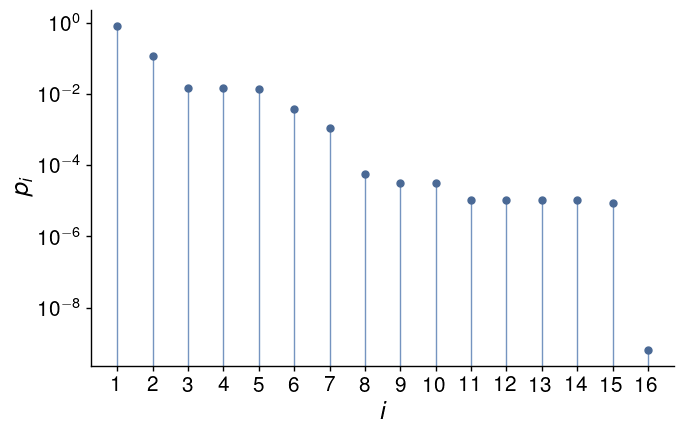

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH = 72
FIGSIZE = (500 / PT_PER_INCH, 320 / PT_PER_INCH)
font_scale = 1.5
label_fs = int(12 * font_scale)
tick_labelsize = int(10 * font_scale)

# Assume rho_final and psi_target are defined
eigvals, eigvecs = np.linalg.eigh(rho_final)
eigvals_sorted = np.sort(eigvals)[::-1]
d = len(eigvals_sorted)

# Principal eigenvector fidelity
principal_index = np.argmax(eigvals)
psi_principal = eigvecs[:, principal_index]
pfidelity = np.abs(np.vdot(psi_target, psi_principal))**2

# ideal fidelity using rho+analytic formula
result = rho_final + (2/3) * (rho_final @ rho_final) - (2/3) * np.trace(rho_final @ rho_final) * rho_final
theory_max_fidelity = np.real(psi_target.conj().T @ result @ psi_target)

print("Fidelity:", fidelity)
print("Fidelity between principal eigenvector and target state:", pfidelity)
print("largest eigenval:", eigvals_sorted[0:5])
psi_principal2 = eigvecs[:, 14]
pfidelity2 = np.abs(np.vdot(psi_target, psi_principal2))**2
print("Fidelity between second principal eigenvector and target state:", pfidelity2)
print("Second largest eigenval:", eigvals_sorted[1])
print("Theoretically max fidelity:", theory_max_fidelity)

# --- Full spectrum plot (rank 1 = largest eigenvalue, leftmost) ---
fig, ax = plt.subplots(figsize=FIGSIZE)
x_vals = list(range(1, d + 1))  # rank 1..d left to right
y_vals = eigvals_sorted          # descending, so rank 1 is largest

for x, y in zip(x_vals, y_vals):
    ax.plot([x, x], [0, y], color="#7594C0", linewidth=1)
    ax.plot(x, y, 'o', color="#4A6995", markersize=5)

ax.set_xticks(x_vals)
ax.set_xticklabels([str(i) for i in x_vals])
ax.set_xlabel(r"$i$", fontsize=label_fs)
ax.set_ylabel(r"$p_i$", fontsize=label_fs)
ax.set_yscale('log')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)

fig.tight_layout()
fig.savefig("spectrum_rho.svg")
plt.show()

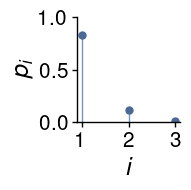

In [14]:
PT_PER_INCH = 72
FIGSIZE_INSET = (144 / PT_PER_INCH, 144 / PT_PER_INCH)  # 2x2 inches in pt notation
font_scale = 1.5
label_fs = int(12 * font_scale)
tick_labelsize = int(10 * font_scale)

# --- Inset: top eigenvalues only (rank 1 = largest, leftmost) ---
n_show = d - 13
x_vals = list(range(1, n_show + 1))  # [1, 2, ..., n_show]
y_vals = eigvals_sorted[:n_show]      # top n_show eigenvalues (descending)

fig, ax = plt.subplots(figsize=FIGSIZE_INSET)
for x, y in zip(x_vals, y_vals):
    ax.plot([x, x], [0, y], color="#7594C0", linewidth=1)
    ax.plot(x, y, 'o', color="#4A6995", markersize=5)

ax.set_xticks(x_vals)
ax.set_xticklabels([str(i) for i in x_vals])
ax.set_xlabel(r"$i$", fontsize=label_fs)
ax.set_ylabel(r"$p_i$", fontsize=label_fs)
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)

fig.tight_layout()
fig.savefig("spectrum_rho_inset.svg")
plt.show()

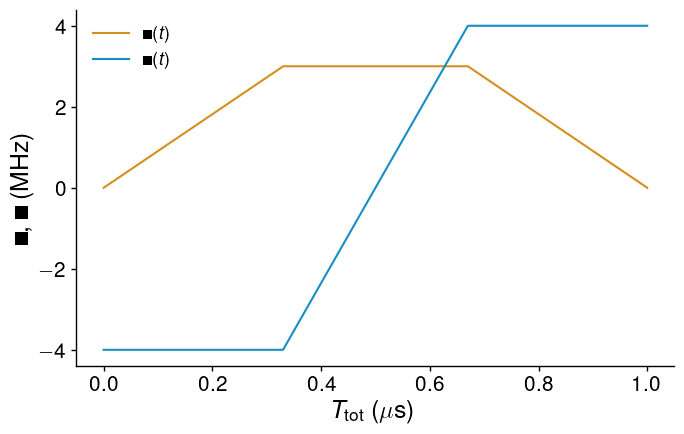

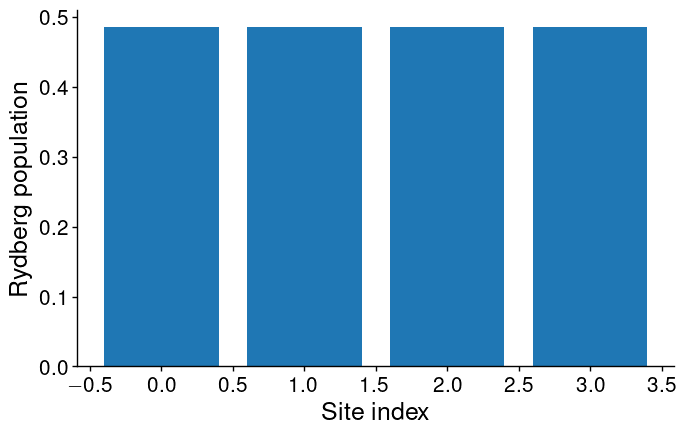

In [12]:
PT_PER_INCH = 72
FIGSIZE = (500 / PT_PER_INCH, 320 / PT_PER_INCH)
font_scale = 1.5
label_fs = int(12 * font_scale)
tick_labelsize = int(10 * font_scale)
legend_fs = int(9 * font_scale)

# --- observables: Rydberg density on each site ---
densities = [np.trace(rho_t @ Pr_ops[j]).real for j in range(k)]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(t_grid * 1e6, Omega_t / (2 * np.pi * 1e6), label=r"$\Omega(t)$", color='#d78e20')
ax.plot(t_grid * 1e6, Delta_t / (2 * np.pi * 1e6), label=r"$\Delta(t)$", color='#158fc2')
ax.set_xlabel(r"$T_{\mathrm{tot}}$ ($\mu$s)", fontsize=label_fs)
ax.set_ylabel(r"$\Omega$, $\Delta$ (MHz)", fontsize=label_fs)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.legend(frameon=False, fontsize=legend_fs)
fig.tight_layout()
fig.savefig("amplitude.svg")
plt.show()

fig2, ax2 = plt.subplots(figsize=FIGSIZE)
ax2.bar(range(k), densities)
ax2.set_xlabel("Site index", fontsize=label_fs)
ax2.set_ylabel("Rydberg population", fontsize=label_fs)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_linewidth(1)
ax2.spines["bottom"].set_linewidth(1)
ax2.xaxis.set_ticks_position("bottom")
ax2.yaxis.set_ticks_position("left")
ax2.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
fig2.tight_layout()
plt.show()

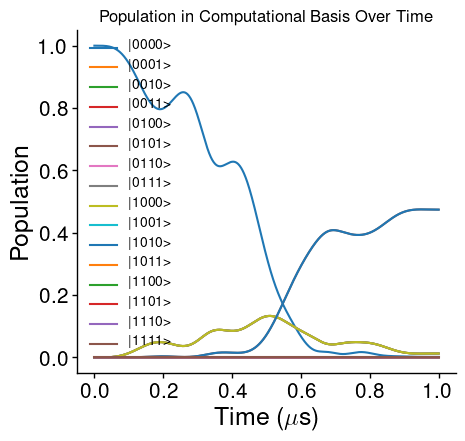

In [6]:
PT_PER_INCH = 72
font_scale = 1.5
label_fs = int(12 * font_scale)
tick_labelsize = int(10 * font_scale)

# --- evolution of population ---
fig, ax = plt.subplots(figsize=(345 / PT_PER_INCH, 325 / PT_PER_INCH))
for i in range(d):
    ax.plot(t_grid * 1e6, populations[:, i], label=f"|{format(i, f'0{k}b')}>")
ax.set_xlabel(r"Time ($\mu$s)", fontsize=label_fs)
ax.set_ylabel("Population", fontsize=label_fs)
ax.set_title("Population in Computational Basis Over Time")
ax.legend(fontsize=int(7 * font_scale), frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
fig.tight_layout()
plt.show()